In [1]:
# %%
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# %%
EMBEDDINGS_DIR = Path("embeddings")

GOLDEN_LABEL = "Qwen3-Embedding-0.6B-f16.gguf"
GOLDEN_PATH = EMBEDDINGS_DIR / f"{GOLDEN_LABEL}.json"

OUTPUT_DIR = Path("outputs_pairwise_similarity_matrix")
OUTPUT_DIR.mkdir(exist_ok=True)

assert EMBEDDINGS_DIR.exists(), f"Directory not found: {EMBEDDINGS_DIR.resolve()}"
assert GOLDEN_PATH.exists(), f"Golden file not found: {GOLDEN_PATH.resolve()}"

json_paths = sorted(EMBEDDINGS_DIR.glob("*.json"))

print("Found files:")
for path in json_paths:
    print("-", path.name)

Found files:
- Qwen3-Embedding-0.6B-Q8_0.gguf.json
- Qwen3-Embedding-0.6B-f16.gguf.json
- Qwen3-Embedding-0.6B.i1-Q2_K.gguf.json
- Qwen3-Embedding-0.6B.i1-Q3_K_M.gguf.json
- Qwen3-Embedding-0.6B.i1-Q4_K_M.gguf.json
- Qwen3-Embedding-0.6B.i1-Q5_K_M.gguf.json
- Qwen3-Embedding-0.6B.i1-Q6_K.gguf.json


In [3]:
# %%
def load_embedding_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def flatten_embedding_file(path: Path) -> pd.DataFrame:
    data = load_embedding_json(path)
    label = path.stem

    rows = []

    groups = data.get("groups")
    if not isinstance(groups, dict):
        raise ValueError(f"Invalid JSON format: groups not found in {path}")

    for group_name, group_data in groups.items():
        items = group_data.get("items")
        if not isinstance(items, list):
            raise ValueError(f"Invalid JSON format: groups.{group_name}.items not found in {path}")

        for item in items:
            embedding = item.get("embedding")
            if embedding is None:
                raise ValueError(f"Embedding missing: {path}, group={group_name}, item={item}")

            rows.append({
                "label": label,
                "group": group_name,
                "index": int(item["index"]),
                "text": item["text"],
                "dimension": len(embedding),
                "embedding": np.asarray(embedding, dtype=np.float32),
            })

    return pd.DataFrame(rows)


all_df = pd.concat(
    [flatten_embedding_file(path) for path in json_paths],
    ignore_index=True,
)

display(all_df.head())

,label,group,index,text,dimension,embedding
0,Qwen3-Embedding-0.6B-Q8_0.gguf,words,0,회사원,1024,"[-0.0030338056, -0.15160239, -0.011095128, -0...."
1,Qwen3-Embedding-0.6B-Q8_0.gguf,words,1,살해범,1024,"[-0.011650151, -0.01508228, -0.011664755, 0.04..."
2,Qwen3-Embedding-0.6B-Q8_0.gguf,words,2,수캐,1024,"[0.01099435, -0.019578675, -0.013508767, 0.023..."
3,Qwen3-Embedding-0.6B-Q8_0.gguf,words,3,퍼덕이다,1024,"[0.016206378, -0.011092099, -0.014384843, -0.0..."
4,Qwen3-Embedding-0.6B-Q8_0.gguf,words,4,마그마,1024,"[-0.010670422, -0.027787939, -0.012867507, -0...."


In [4]:
# %%
def normalize_matrix(x: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.clip(norms, 1e-12, None)


def cosine_similarity_matrix(x: np.ndarray) -> np.ndarray:
    x = normalize_matrix(x)
    return x @ x.T


def upper_triangle_values(matrix: np.ndarray) -> np.ndarray:
    indices = np.triu_indices_from(matrix, k=1)
    return matrix[indices]


def build_embedding_matrix(df: pd.DataFrame, label: str, group: str):
    target = df[(df["label"] == label) & (df["group"] == group)].copy()
    target = target.sort_values(["group", "index"]).reset_index(drop=True)

    texts = target["text"].tolist()
    embeddings = np.stack(target["embedding"].to_numpy())

    return texts, embeddings


def short_model_label(label: str) -> str:
    prefix = "Qwen3-Embedding-0.6B-"
    suffix = ".gguf"

    name = label

    if name.startswith(prefix):
        name = name[len(prefix):]

    if name.endswith(suffix):
        name = name[:-len(suffix)]

    return name

In [5]:
# %%
GROUP_ORDER = ["words", "sentences", "documents"]

GROUP_LABEL_MAP = {
    "words": "words",
    "sentences": "sentences",
    "documents": "documents",
}


matrix_rows = []
matrix_detail_rows = []

labels = sorted(label for label in all_df["label"].unique() if label != GOLDEN_LABEL)

for label in labels:
    for group in GROUP_ORDER:
        golden_texts, golden_emb = build_embedding_matrix(all_df, GOLDEN_LABEL, group)
        model_texts, model_emb = build_embedding_matrix(all_df, label, group)

        if len(golden_texts) < 2:
            continue

        if golden_texts != model_texts:
            raise ValueError(f"text order mismatch: label={label}, group={group}")

        golden_sim = cosine_similarity_matrix(golden_emb)
        model_sim = cosine_similarity_matrix(model_emb)

        golden_values = upper_triangle_values(golden_sim)
        model_values = upper_triangle_values(model_sim)

        diff = model_values - golden_values
        abs_diff = np.abs(diff)

        mae = float(np.mean(abs_diff))
        rmse = float(np.sqrt(np.mean(diff ** 2)))
        max_error = float(np.max(abs_diff))

        if len(golden_values) >= 2 and np.std(golden_values) > 0 and np.std(model_values) > 0:
            corr = float(np.corrcoef(golden_values, model_values)[0, 1])
        else:
            corr = float("nan")

        matrix_rows.append({
            "label": label,
            "group": group,
            "pair_count": len(golden_values),
            "pairwise_similarity_mae": mae,
            "pairwise_similarity_rmse": rmse,
            "pairwise_similarity_max_error": max_error,
            "pairwise_similarity_correlation": corr,
        })

        pair_index = 0
        for i in range(len(golden_texts)):
            for j in range(i + 1, len(golden_texts)):
                matrix_detail_rows.append({
                    "label": label,
                    "group": group,
                    "left_index": i,
                    "right_index": j,
                    "left_text": golden_texts[i],
                    "right_text": golden_texts[j],
                    "golden_similarity": float(golden_sim[i, j]),
                    "model_similarity": float(model_sim[i, j]),
                    "diff": float(model_sim[i, j] - golden_sim[i, j]),
                    "abs_diff": float(abs(model_sim[i, j] - golden_sim[i, j])),
                })
                pair_index += 1


matrix_df = pd.DataFrame(matrix_rows)
matrix_detail_df = pd.DataFrame(matrix_detail_rows)

display(
    matrix_df.sort_values(
        ["group", "pairwise_similarity_mae"],
        ascending=[True, True],
    )
)

,label,group,pair_count,pairwise_similarity_mae,pairwise_similarity_rmse,pairwise_similarity_max_error,pairwise_similarity_correlation
2,Qwen3-Embedding-0.6B-Q8_0.gguf,documents,44850,0.002264,0.002853,0.013681,0.999299
17,Qwen3-Embedding-0.6B.i1-Q6_K.gguf,documents,44850,0.004270,0.005370,0.023085,0.997483
14,Qwen3-Embedding-0.6B.i1-Q5_K_M.gguf,documents,44850,0.007898,0.009897,0.041410,0.993399
11,Qwen3-Embedding-0.6B.i1-Q4_K_M.gguf,documents,44850,0.016469,0.020076,0.075781,0.981213
8,Qwen3-Embedding-0.6B.i1-Q3_K_M.gguf,documents,44850,0.020965,0.026384,0.118685,0.937977
5,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,documents,44850,0.190725,0.196425,0.384506,0.790281
1,Qwen3-Embedding-0.6B-Q8_0.gguf,sentences,499500,0.002711,0.003452,0.029940,0.999298
16,Qwen3-Embedding-0.6B.i1-Q6_K.gguf,sentences,499500,0.006265,0.007889,0.056708,0.997090
13,Qwen3-Embedding-0.6B.i1-Q5_K_M.gguf,sentences,499500,0.010033,0.012730,0.076165,0.992016
10,Qwen3-Embedding-0.6B.i1-Q4_K_M.gguf,sentences,499500,0.014993,0.019066,0.116220,0.978520


saved: outputs_pairwise_similarity_matrix/pairwise_words_pairwise_similarity_mae.png


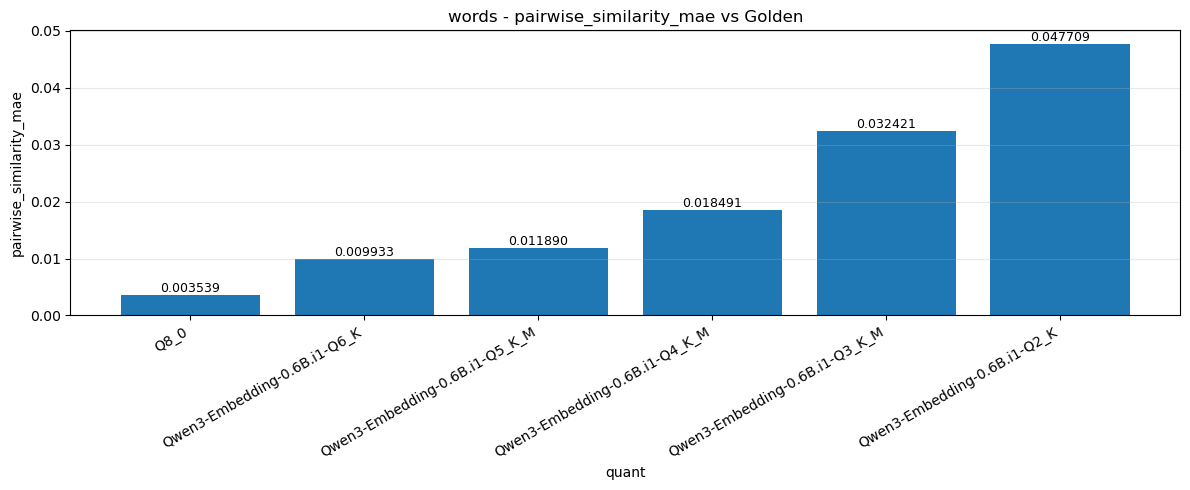

saved: outputs_pairwise_similarity_matrix/pairwise_sentences_pairwise_similarity_mae.png


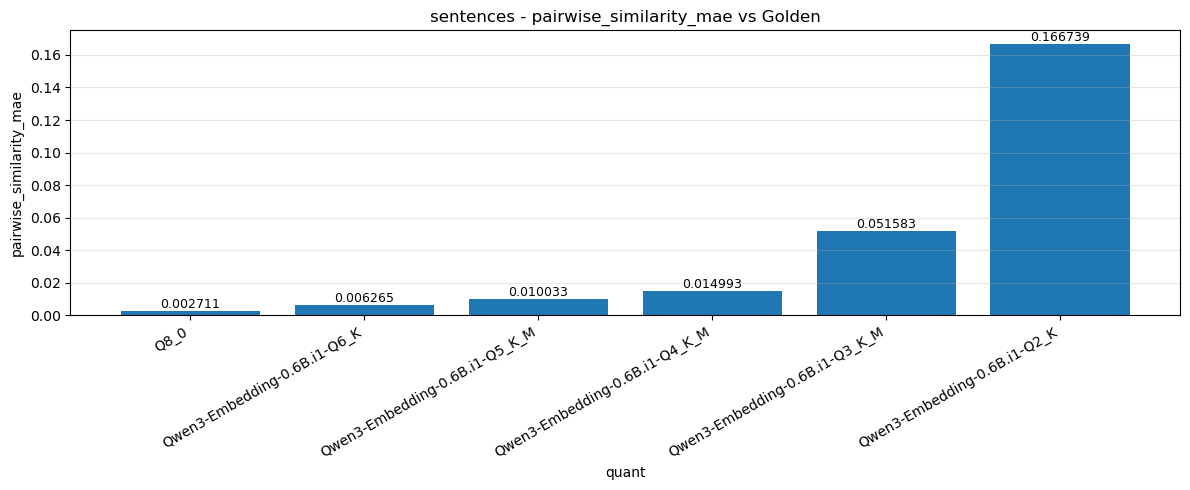

saved: outputs_pairwise_similarity_matrix/pairwise_documents_pairwise_similarity_mae.png


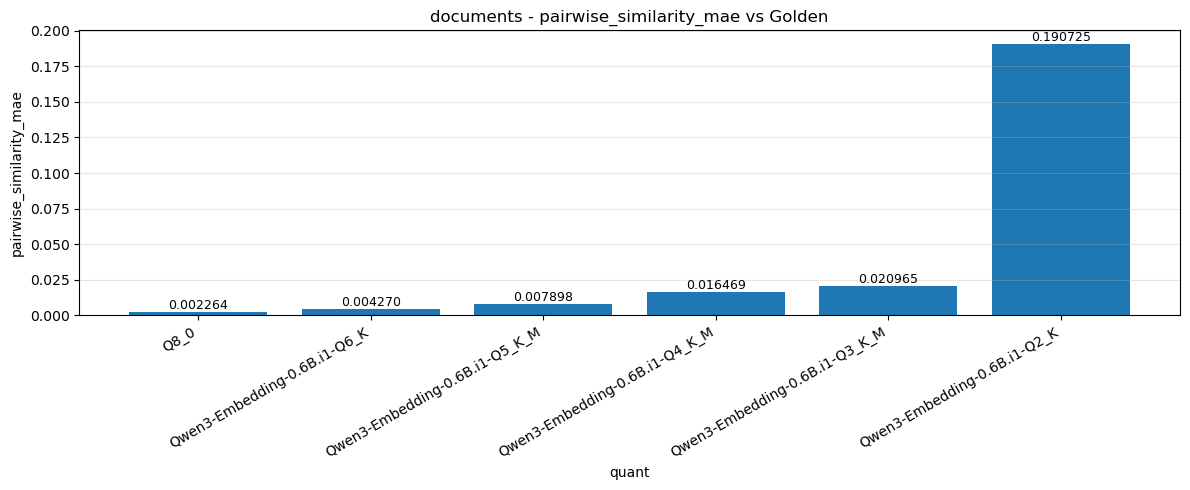

In [6]:
# %%
def plot_pairwise_metric_by_group(
    group_name: str,
    metric: str = "pairwise_similarity_mae",
    ascending: bool = True,
):
    target = matrix_df[matrix_df["group"] == group_name].copy()

    if target.empty:
        print(f"[SKIP] group={group_name}")
        return None

    target = target.sort_values(metric, ascending=ascending)
    target["display_label"] = target["label"].map(short_model_label)

    fig = plt.figure(figsize=(12, 5))
    ax = plt.gca()

    bars = ax.bar(
        target["display_label"],
        target[metric],
    )

    group_display_name = GROUP_LABEL_MAP.get(group_name, group_name)

    ax.set_title(f"{group_display_name} - {metric} vs Golden")
    ax.set_xlabel("quant")
    ax.set_ylabel(metric)
    ax.grid(axis="y", alpha=0.3)

    plt.xticks(rotation=30, ha="right")

    for bar, value in zip(bars, target[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.6f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()

    output_path = OUTPUT_DIR / f"pairwise_{group_name}_{metric}.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"saved: {output_path}")

    plt.show()

    return target


for group_name in GROUP_ORDER:
    plot_pairwise_metric_by_group(
        group_name=group_name,
        metric="pairwise_similarity_mae",
        ascending=True,
    )

saved: outputs_pairwise_similarity_matrix/pairwise_words_pairwise_similarity_correlation.png


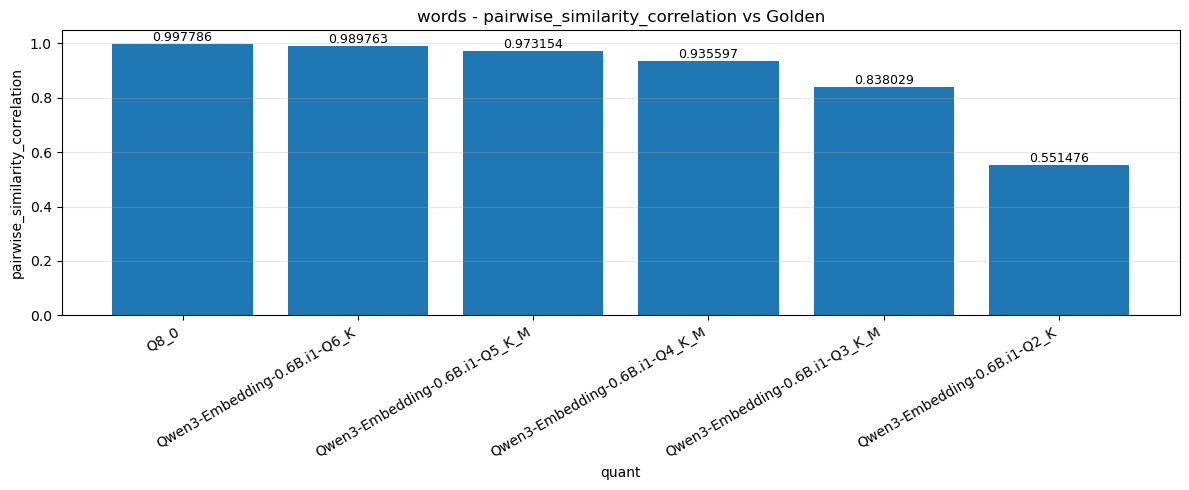

saved: outputs_pairwise_similarity_matrix/pairwise_sentences_pairwise_similarity_correlation.png


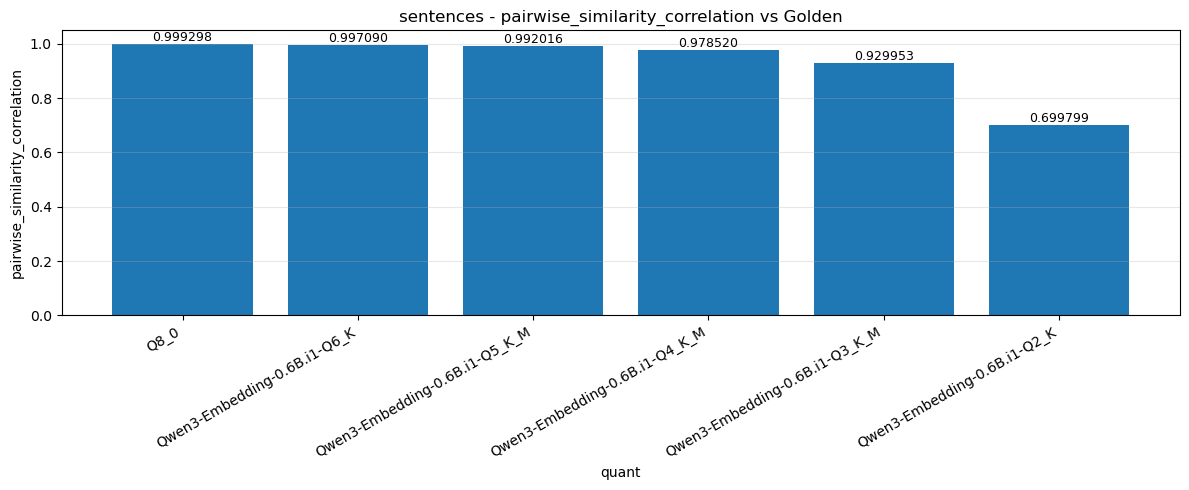

saved: outputs_pairwise_similarity_matrix/pairwise_documents_pairwise_similarity_correlation.png


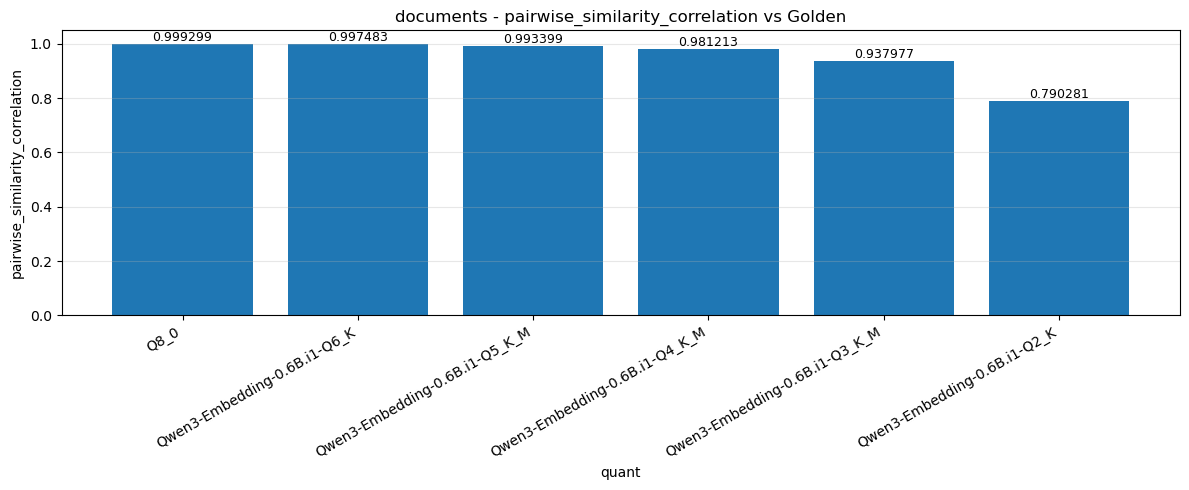

In [7]:
# %%
# correlation은 높을수록 좋으므로 ascending=False

for group_name in GROUP_ORDER:
    plot_pairwise_metric_by_group(
        group_name=group_name,
        metric="pairwise_similarity_correlation",
        ascending=False,
    )

In [11]:
# %%
# 가장 많이 틀어진 pair 확인

worst_pairs = (
    matrix_detail_df
    .sort_values("abs_diff", ascending=False)
    .loc[:, [
        "label",
        "group",
        "left_index",
        "right_index",
        "golden_similarity",
        "model_similarity",
        "diff",
        "abs_diff",
        "left_text",
        "right_text",
    ]]
)

display(worst_pairs.head(30))

,label,group,left_index,right_index,golden_similarity,model_similarity,diff,abs_diff,left_text,right_text
1775452,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,268,417,0.009065,0.553730,0.544665,0.544665,어두운 방안 밝기 조정은 뭘해야 할 수 있는거야?,"빠른 연락, 너무 깨끗하고 아름다운 집과 정원 그리고 무엇보다 너무 친절했던 두분은..."
1775500,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,268,465,0.082359,0.543615,0.461255,0.461255,어두운 방안 밝기 조정은 뭘해야 할 수 있는거야?,"친절함, 청결함, 그로브 몰까지 걸어가는 모든 것이 좋았어요!"
1775514,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,268,479,0.073861,0.532833,0.458972,0.458972,어두운 방안 밝기 조정은 뭘해야 할 수 있는거야?,"위치, 시설, 조용함, 청결 등 모든면에서 나에게는 대단히 좋았었습니다."
2029751,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,837,942,0.069959,0.526657,0.456698,0.456698,겨울철에 난방 적정 온도가 몇이야?,약속을 취소하면 앞으로 사람들이 널 믿을 수 있을까?
1749888,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,234,268,0.084729,0.536898,0.452168,0.452168,제가 묵었던 숙소는 단연코 제가 제일이었던 것 같아요!,어두운 방안 밝기 조정은 뭘해야 할 수 있는거야?
1873616,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,417,837,0.005452,0.454398,0.448946,0.448946,"빠른 연락, 너무 깨끗하고 아름다운 집과 정원 그리고 무엇보다 너무 친절했던 두분은...",겨울철에 난방 적정 온도가 몇이야?
1643792,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,106,220,0.101386,0.549744,0.448357,0.448357,쾌적한 안방 온도로 적정 온도는 몇도 정도 돼?,메일 중에 첨부파일 용량이 큰 것은 반드시 모두 지워주세요. 용량이 작은 메일은 지...
1549590,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,6,268,0.121017,0.568555,0.447537,0.447537,엘레베이터가 있는 점과 야외 계단을 이용할 수 있다는 점이 가장 맘에 들었습니다.,어두운 방안 밝기 조정은 뭘해야 할 수 있는거야?
1643516,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,105,837,0.137753,0.584066,0.446313,0.446313,지난해 4월 산불을 내 0.57㏊의 피해를 낸 A씨에게는 징역 5년이 선고되기도 했다.,겨울철에 난방 적정 온도가 몇이야?
1775801,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,268,766,0.069381,0.514271,0.444890,0.444890,어두운 방안 밝기 조정은 뭘해야 할 수 있는거야?,체크인 전이나 체크아웃 후에 짐을 맡길 수 있어서 좋았습니다.


In [12]:
worst_pairs_view = worst_pairs.copy()

worst_pairs_view["direction"] = np.where(
    worst_pairs_view["diff"] > 0,
    "1 양자화 모델이 더 비슷하게 봄",
    "0 양자화 모델이 덜 비슷하게 봄",
)

worst_pairs_view["pair_summary"] = (
    "[" + worst_pairs_view["group"] + "] "
    + worst_pairs_view["left_text"].str.slice(0, 40)
    + "  <->  "
    + worst_pairs_view["right_text"].str.slice(0, 40)
)

display(
    worst_pairs_view[
        [
            "label",
            "group",
            "golden_similarity",
            "model_similarity",
            "diff",
            "abs_diff",
            "direction",
            "left_text",
            "right_text",
        ]
    ].head(30)
)

,label,group,golden_similarity,model_similarity,diff,abs_diff,direction,left_text,right_text
1775452,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,0.009065,0.553730,0.544665,0.544665,1 양자화 모델이 더 비슷하게 봄,어두운 방안 밝기 조정은 뭘해야 할 수 있는거야?,"빠른 연락, 너무 깨끗하고 아름다운 집과 정원 그리고 무엇보다 너무 친절했던 두분은..."
1775500,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,0.082359,0.543615,0.461255,0.461255,1 양자화 모델이 더 비슷하게 봄,어두운 방안 밝기 조정은 뭘해야 할 수 있는거야?,"친절함, 청결함, 그로브 몰까지 걸어가는 모든 것이 좋았어요!"
1775514,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,0.073861,0.532833,0.458972,0.458972,1 양자화 모델이 더 비슷하게 봄,어두운 방안 밝기 조정은 뭘해야 할 수 있는거야?,"위치, 시설, 조용함, 청결 등 모든면에서 나에게는 대단히 좋았었습니다."
2029751,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,0.069959,0.526657,0.456698,0.456698,1 양자화 모델이 더 비슷하게 봄,겨울철에 난방 적정 온도가 몇이야?,약속을 취소하면 앞으로 사람들이 널 믿을 수 있을까?
1749888,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,0.084729,0.536898,0.452168,0.452168,1 양자화 모델이 더 비슷하게 봄,제가 묵었던 숙소는 단연코 제가 제일이었던 것 같아요!,어두운 방안 밝기 조정은 뭘해야 할 수 있는거야?
1873616,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,0.005452,0.454398,0.448946,0.448946,1 양자화 모델이 더 비슷하게 봄,"빠른 연락, 너무 깨끗하고 아름다운 집과 정원 그리고 무엇보다 너무 친절했던 두분은...",겨울철에 난방 적정 온도가 몇이야?
1643792,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,0.101386,0.549744,0.448357,0.448357,1 양자화 모델이 더 비슷하게 봄,쾌적한 안방 온도로 적정 온도는 몇도 정도 돼?,메일 중에 첨부파일 용량이 큰 것은 반드시 모두 지워주세요. 용량이 작은 메일은 지...
1549590,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,0.121017,0.568555,0.447537,0.447537,1 양자화 모델이 더 비슷하게 봄,엘레베이터가 있는 점과 야외 계단을 이용할 수 있다는 점이 가장 맘에 들었습니다.,어두운 방안 밝기 조정은 뭘해야 할 수 있는거야?
1643516,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,0.137753,0.584066,0.446313,0.446313,1 양자화 모델이 더 비슷하게 봄,지난해 4월 산불을 내 0.57㏊의 피해를 낸 A씨에게는 징역 5년이 선고되기도 했다.,겨울철에 난방 적정 온도가 몇이야?
1775801,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,0.069381,0.514271,0.444890,0.444890,1 양자화 모델이 더 비슷하게 봄,어두운 방안 밝기 조정은 뭘해야 할 수 있는거야?,체크인 전이나 체크아웃 후에 짐을 맡길 수 있어서 좋았습니다.


saved: outputs_pairwise_similarity_matrix/pairwise_scatter_Q8_0_words.png


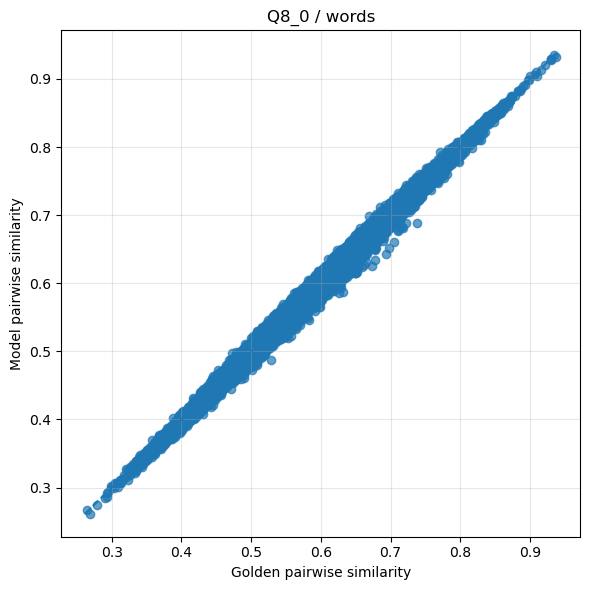

saved: outputs_pairwise_similarity_matrix/pairwise_scatter_Q8_0_sentences.png


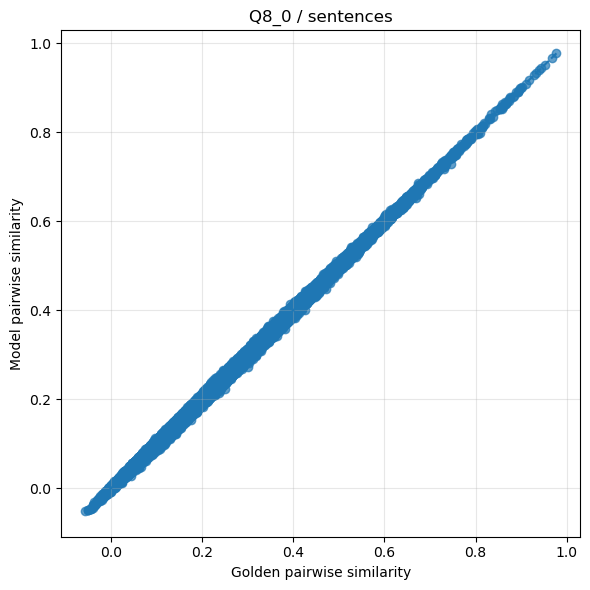

saved: outputs_pairwise_similarity_matrix/pairwise_scatter_Q8_0_documents.png


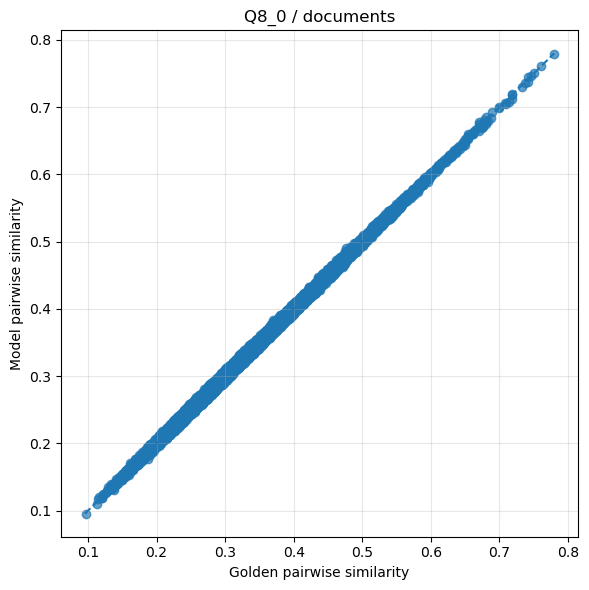

saved: outputs_pairwise_similarity_matrix/pairwise_scatter_Qwen3-Embedding-0.6B.i1-Q2_K_words.png


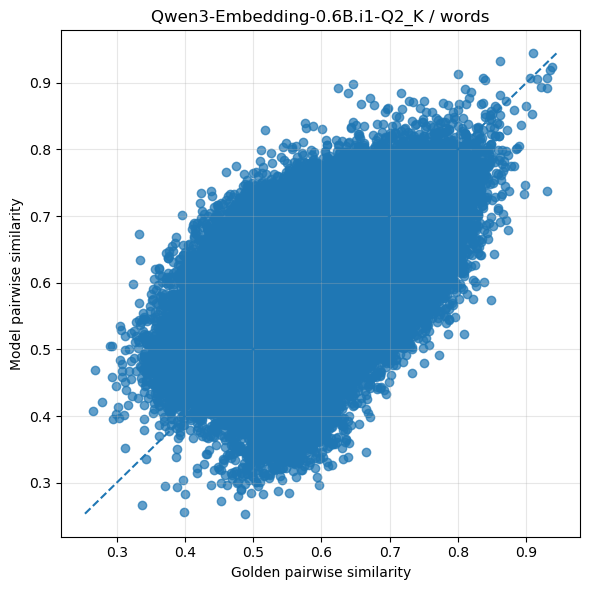

saved: outputs_pairwise_similarity_matrix/pairwise_scatter_Qwen3-Embedding-0.6B.i1-Q2_K_sentences.png


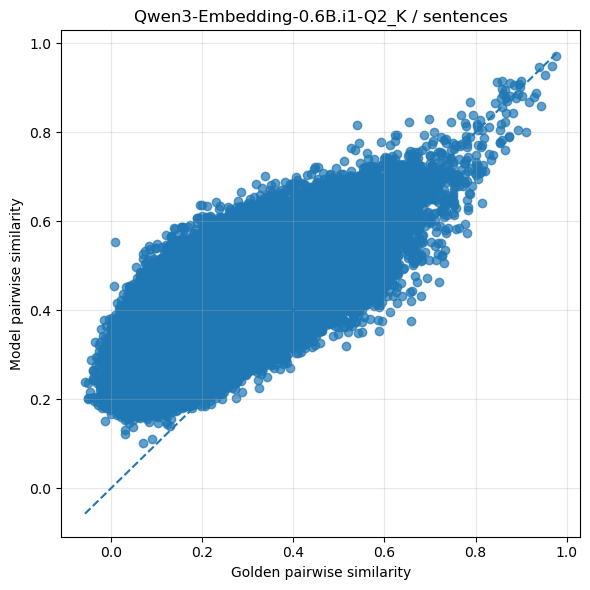

saved: outputs_pairwise_similarity_matrix/pairwise_scatter_Qwen3-Embedding-0.6B.i1-Q2_K_documents.png


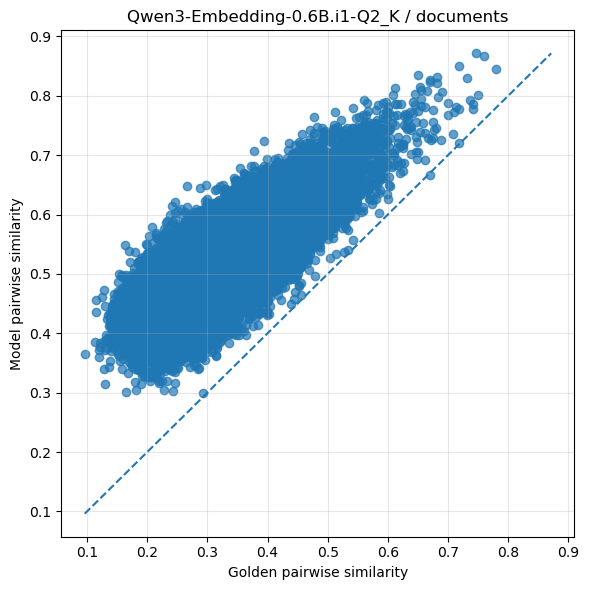

saved: outputs_pairwise_similarity_matrix/pairwise_scatter_Qwen3-Embedding-0.6B.i1-Q3_K_M_words.png


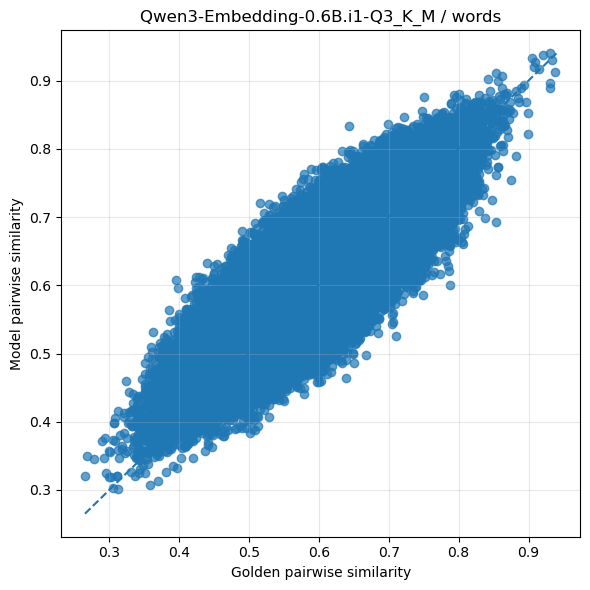

saved: outputs_pairwise_similarity_matrix/pairwise_scatter_Qwen3-Embedding-0.6B.i1-Q3_K_M_sentences.png


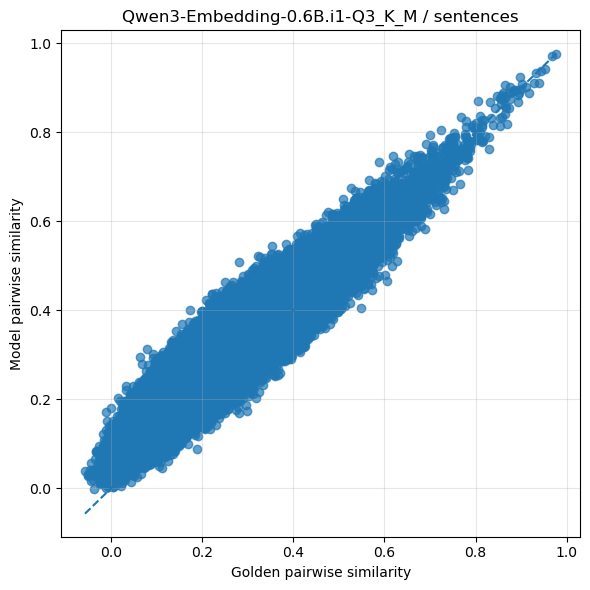

saved: outputs_pairwise_similarity_matrix/pairwise_scatter_Qwen3-Embedding-0.6B.i1-Q3_K_M_documents.png


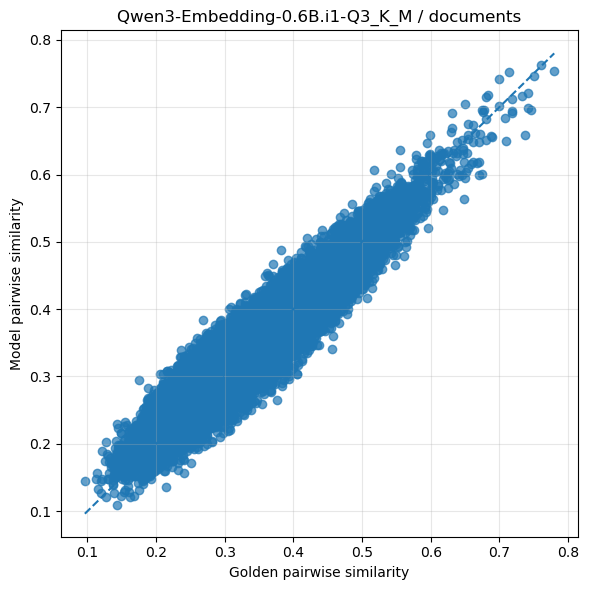

saved: outputs_pairwise_similarity_matrix/pairwise_scatter_Qwen3-Embedding-0.6B.i1-Q4_K_M_words.png


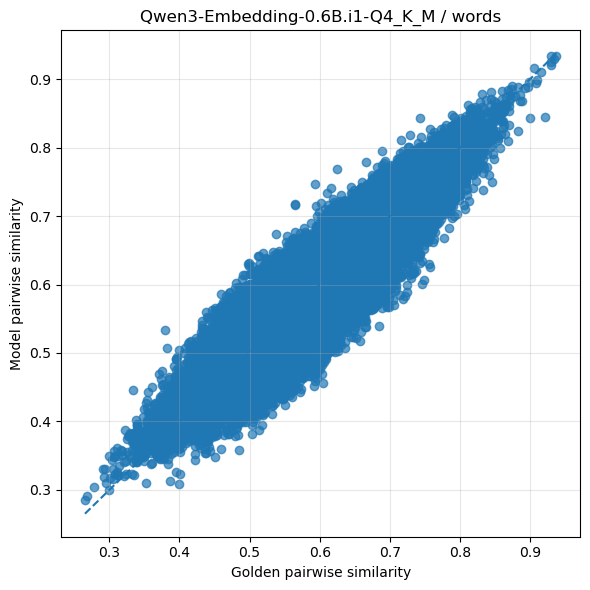

saved: outputs_pairwise_similarity_matrix/pairwise_scatter_Qwen3-Embedding-0.6B.i1-Q4_K_M_sentences.png


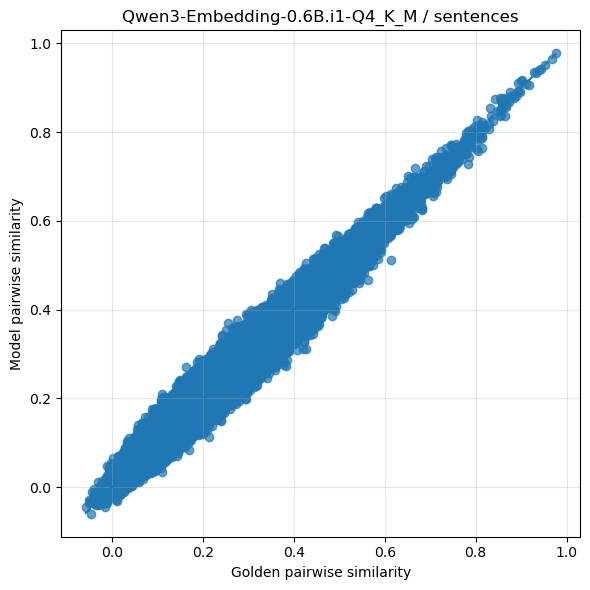

saved: outputs_pairwise_similarity_matrix/pairwise_scatter_Qwen3-Embedding-0.6B.i1-Q4_K_M_documents.png


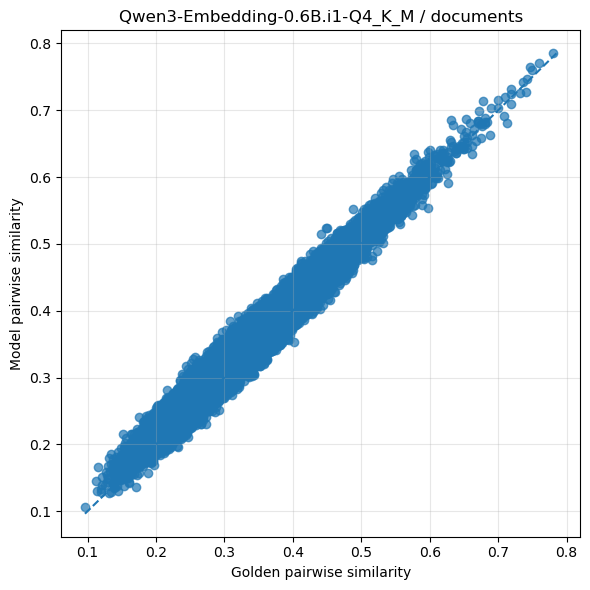

saved: outputs_pairwise_similarity_matrix/pairwise_scatter_Qwen3-Embedding-0.6B.i1-Q5_K_M_words.png


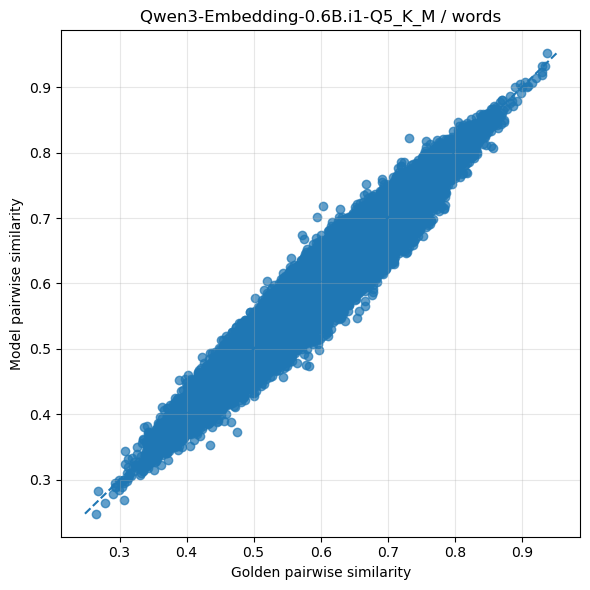

saved: outputs_pairwise_similarity_matrix/pairwise_scatter_Qwen3-Embedding-0.6B.i1-Q5_K_M_sentences.png


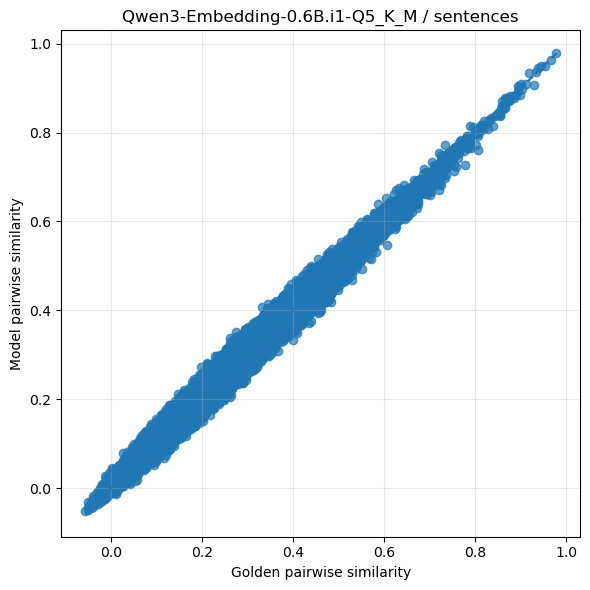

saved: outputs_pairwise_similarity_matrix/pairwise_scatter_Qwen3-Embedding-0.6B.i1-Q5_K_M_documents.png


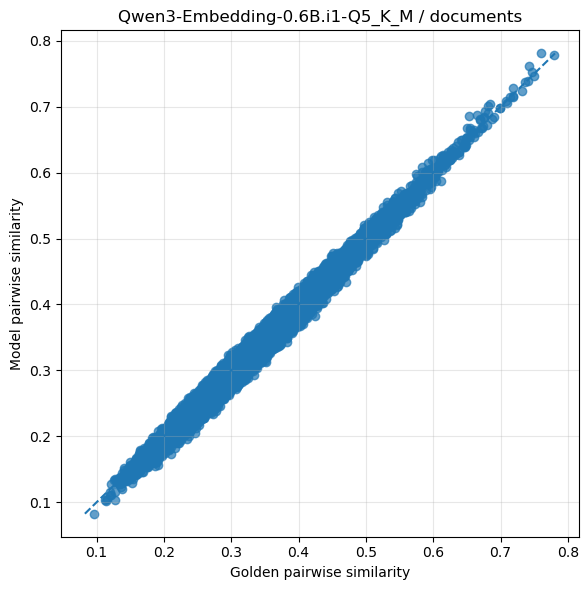

saved: outputs_pairwise_similarity_matrix/pairwise_scatter_Qwen3-Embedding-0.6B.i1-Q6_K_words.png


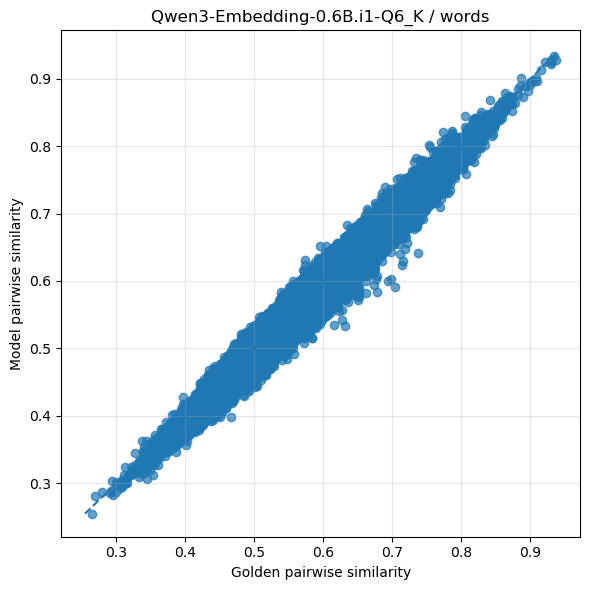

saved: outputs_pairwise_similarity_matrix/pairwise_scatter_Qwen3-Embedding-0.6B.i1-Q6_K_sentences.png


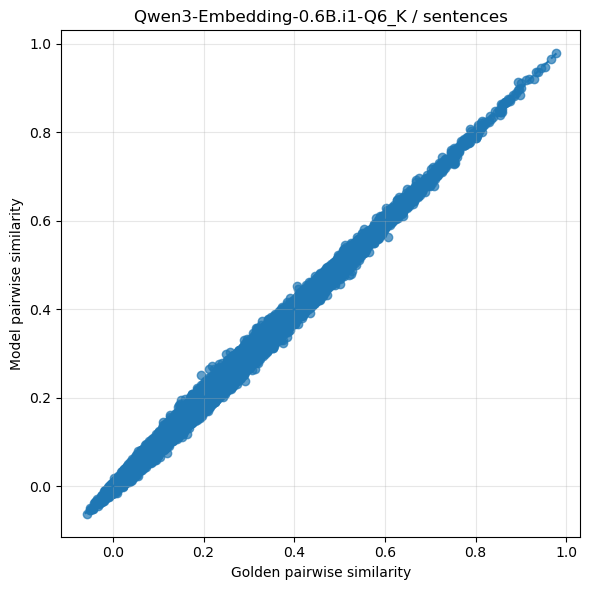

saved: outputs_pairwise_similarity_matrix/pairwise_scatter_Qwen3-Embedding-0.6B.i1-Q6_K_documents.png


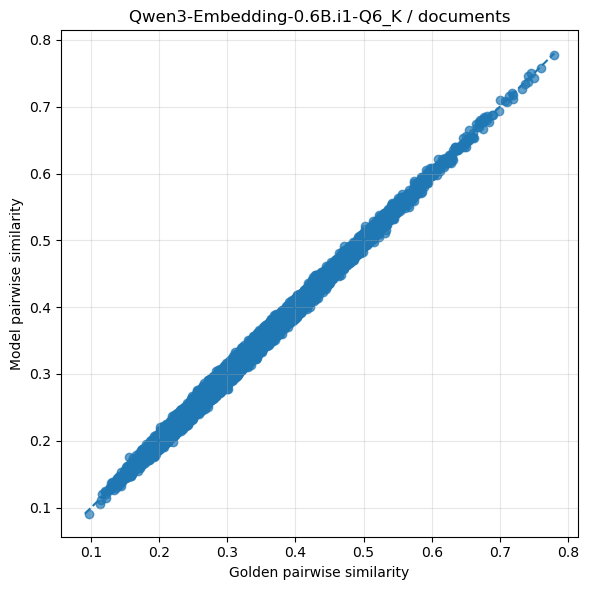

In [10]:
# %%
# 모델별로 golden vs model pairwise similarity 산점도
# 값들이 대각선 y=x 근처에 모이면 pairwise 구조가 잘 유지된 것.

def plot_pairwise_scatter(label: str, group_name: str):
    target = matrix_detail_df[
        (matrix_detail_df["label"] == label)
        & (matrix_detail_df["group"] == group_name)
    ].copy()

    if target.empty:
        print(f"[SKIP] label={label}, group={group_name}")
        return

    fig = plt.figure(figsize=(6, 6))
    ax = plt.gca()

    ax.scatter(
        target["golden_similarity"],
        target["model_similarity"],
        alpha=0.7,
    )

    min_value = min(target["golden_similarity"].min(), target["model_similarity"].min())
    max_value = max(target["golden_similarity"].max(), target["model_similarity"].max())

    ax.plot([min_value, max_value], [min_value, max_value], linestyle="--")

    ax.set_title(f"{short_model_label(label)} / {GROUP_LABEL_MAP.get(group_name, group_name)}")
    ax.set_xlabel("Golden pairwise similarity")
    ax.set_ylabel("Model pairwise similarity")
    ax.grid(alpha=0.3)

    plt.tight_layout()

    output_path = OUTPUT_DIR / f"pairwise_scatter_{short_model_label(label)}_{group_name}.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"saved: {output_path}")

    plt.show()


for label in labels:
    for group_name in GROUP_ORDER:
        plot_pairwise_scatter(label, group_name)